# Qadence Kickstart: From PyTorch to Quantum Machine Learning

**Lesson 01 of the QML study guide — tensors, autograd, and the training loop.**

This notebook builds the one routine that underlies *all* of machine learning — and, crucially, variational
**quantum** machine learning: **forward → loss → backward → update**. We start from raw autograd, graduate to
`torch.optim`/`nn`, and finish by fitting a plane in a 2-D feature space with proper regression diagnostics.

**Why it matters for QML.** [Qadence](https://docs.pasqal.com/qadence/) trains quantum circuits with PyTorch's
autodiff plus the parameter-shift rule. The optimizer, the loss, the `.backward()` call, the `step()` — all
identical to what you write below. If this loop is comfortable, variational QML training is familiar territory.

> **Series:** this is notebook 1 of 6. Next up: [feature maps & kernels](qadence-kickstart-101-kernels.ipynb)
> — the path toward Pasqal's Quantum Evolution Kernel. No prerequisites; everything runs on a laptop.

## 1. Autograd: gradients for free

Set `requires_grad=True` and PyTorch records every operation into a computation graph. Calling `.backward()`
walks that graph in reverse (the chain rule) and deposits the gradient in `.grad`. You write the *forward*
computation; PyTorch hands you the *gradient*.

In [1]:
import torch

torch.manual_seed(20000)

# y = x^3 + 2x   ->   dy/dx = 3x^2 + 2   ->   at x=2 this is 14
x = torch.tensor(2.0, requires_grad=True)
y = x**3 + 2*x
y.backward()                       # fills x.grad

analytic = 3 * x.item()**2 + 2
print(f"x = {x.item()},  y = {y.item()},  x.grad = {x.grad.item()}  (analytic dy/dx = {analytic})")
assert abs(x.grad.item() - analytic) < 1e-6      # autograd == calculus

x = 2.0,  y = 12.0,  x.grad = 14.0  (analytic dy/dx = 14.0)


## 2. A training loop by hand

Let's fit a line `y = w·x + b` to noisy data, writing the gradient step manually so nothing is hidden. Three
things recur in *every* variational algorithm:

1. **Forward → loss → backward → update** is the universal rhythm.
2. **`grad.zero_()` matters** — gradients *accumulate* by default; forgetting to reset them is the classic
   training bug.
3. **`no_grad()` for the update** — the parameter step is bookkeeping, not part of the differentiated graph.

*Best practice:* record the loss each epoch so you can **see** convergence rather than guess at it.

epoch   0  loss 2.3905  w 0.139  b -0.196
epoch  50  loss 0.0093  w 1.988  b -0.981
epoch 100  loss 0.0081  w 2.042  b -0.981
epoch 150  loss 0.0080  w 2.044  b -0.981
learned: w=2.044, b=-0.981   (true: 2.0, -1.0)


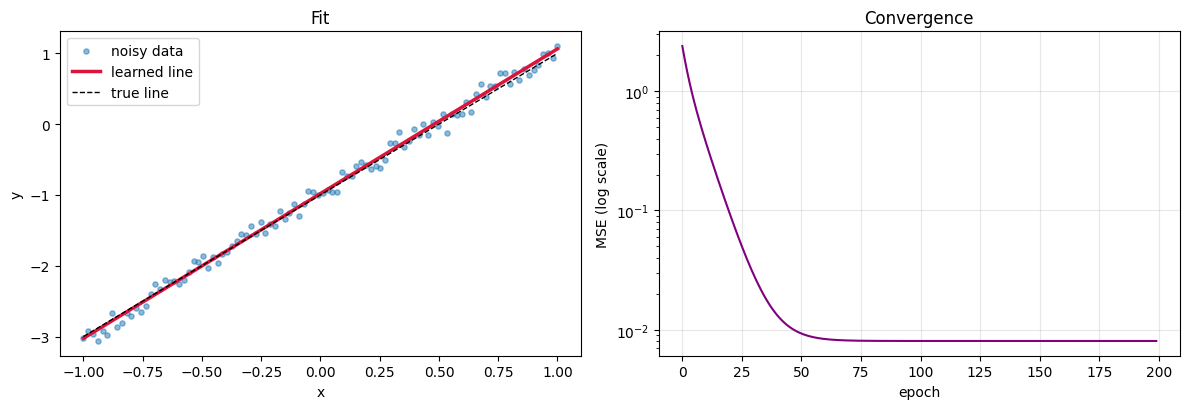

In [2]:
import matplotlib.pyplot as plt

torch.manual_seed(20000)

# synthetic data: true relationship  y = 2x - 1 + noise
X = torch.linspace(-1, 1, 100).unsqueeze(1)      # (100, 1) — unsqueeze makes it a column vector
y = 2 * X - 1 + 0.1 * torch.randn_like(X)        # randn_like: noise with X's shape

# parameters we will learn (start at zero)
w = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr, loss_hist = 0.1, []
for epoch in range(200):
    y_pred = X * w + b                  # forward pass
    loss = ((y_pred - y)**2).mean()     # mean squared error
    loss.backward()                     # fills w.grad, b.grad
    with torch.no_grad():               # don't track the update itself
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_(); b.grad.zero_()  # gradients accumulate; reset them
    loss_hist.append(loss.item())
    if epoch % 50 == 0:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}  w {w.item():.3f}  b {b.item():.3f}")

print(f"learned: w={w.item():.3f}, b={b.item():.3f}   (true: 2.0, -1.0)")

# visualize the fit and the convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.scatter(X, y, s=14, alpha=0.5, label='noisy data')
ax1.plot(X, (X * w + b).detach(), 'crimson', lw=2.5, label='learned line')
ax1.plot(X, 2 * X - 1, 'k--', lw=1, label='true line')
ax1.set_title('Fit'); ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.legend()
ax2.semilogy(loss_hist, color='purple')
ax2.set_title('Convergence'); ax2.set_xlabel('epoch'); ax2.set_ylabel('MSE (log scale)'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. The same loop with `torch.optim` and `nn`

In practice you don't hand-roll the update — `nn.Linear` holds the parameters and an optimizer does the step.
This is the idiomatic form, and the shape a Qadence-style QML program takes: in a variational program `model`
would be a parameterized **quantum circuit** instead of `nn.Linear`, but `opt.zero_grad()` / `loss.backward()`
/ `opt.step()` stay *exactly* the same.

**Optimizers — a common insight worth seeing, not just reading:**

- **SGD** (Stochastic Gradient Descent) — a fixed step size for every parameter; simple, but the learning rate
  needs careful tuning.
- **Adam** (ADAptive Moment estimation) — tracks running averages of the gradient (momentum) and its square,
  adapting a per-parameter step size. Usually converges faster with less tuning.

Below we train the *same* model with both and compare their **loss curves**.

Adam  -> w=1.994, b=-1.009
SGD   -> w=1.994, b=-1.009   (true: 2.0, -1.0)


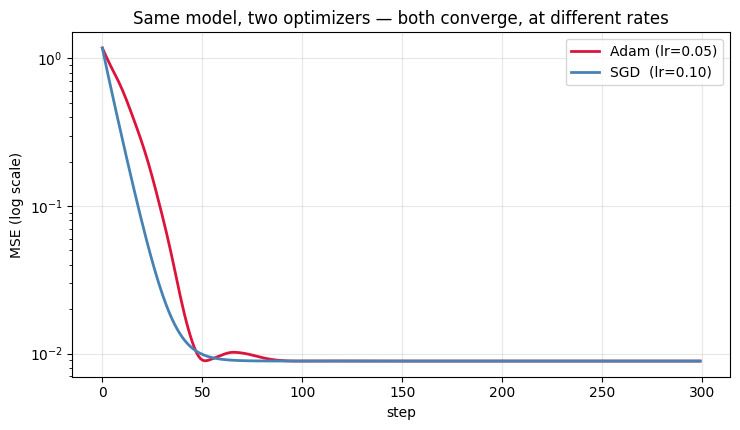

In [3]:
import torch.nn as nn

X = torch.linspace(-1, 1, 100).unsqueeze(1)
y = 2 * X - 1 + 0.1 * torch.randn_like(X)
loss_fn = nn.MSELoss()                 # try nn.L1Loss() for mean-absolute-error instead

def train(optimizer_name, steps=300):
    torch.manual_seed(20000)           # same initial weights -> a fair comparison
    model = nn.Linear(1, 1)            # w and b live inside
    if optimizer_name == 'Adam':
        opt = torch.optim.Adam(model.parameters(), lr=0.05)
    else:
        opt = torch.optim.SGD(model.parameters(), lr=0.1)
    hist = []
    for _ in range(steps):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
        hist.append(loss.item())
    return hist, model.weight.item(), model.bias.item()

adam_hist, wa, ba = train('Adam')
sgd_hist,  ws, bs = train('SGD')
print(f"Adam  -> w={wa:.3f}, b={ba:.3f}")
print(f"SGD   -> w={ws:.3f}, b={bs:.3f}   (true: 2.0, -1.0)")

plt.figure(figsize=(7.5, 4.4))
plt.semilogy(adam_hist, color='crimson',   lw=2, label='Adam (lr=0.05)')
plt.semilogy(sgd_hist,  color='steelblue', lw=2, label='SGD  (lr=0.10)')
plt.xlabel('step'); plt.ylabel('MSE (log scale)'); plt.grid(alpha=0.3)
plt.title('Same model, two optimizers — both converge, at different rates')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Two features: fitting a plane (with proper diagnostics)

Add a second input feature and the model fits a **plane** `ŷ = w₁·X1 + w₂·X2 + b` over the `(X1, X2)` feature
space. We make `X2 = sin(π·X1)`, so the data traces a **curve** through that space.

`nn.Linear(2, 1)` now has a weight of shape `(1, 2)` — one output, two inputs. Instead of staring at a 3-D
surface (which looks "right" whenever the fit is decent), we judge the model the way you should judge *any*
regression, with four standard diagnostics:

- **Residual stems on the fitted plane** — the geometric picture of error (how far each point sits off the plane).
- **Predicted vs actual** — should hug the diagonal `ŷ = y`.
- **Residuals vs input** — should look *structureless*; a pattern means the model is missing something.
- **Coefficient recovery** — learned vs true `w₁, w₂, b`.

We also report the two headline numbers: **MSE** and the **R²** (fraction of variance explained).

weight shape: (1, 2)   bias shape: (1,)
learned : w=[ 2.024 -1.52 ], b=0.314
true    : w=[ 2.  -1.5], b=0.3
MSE=0.0095   R²=0.9838


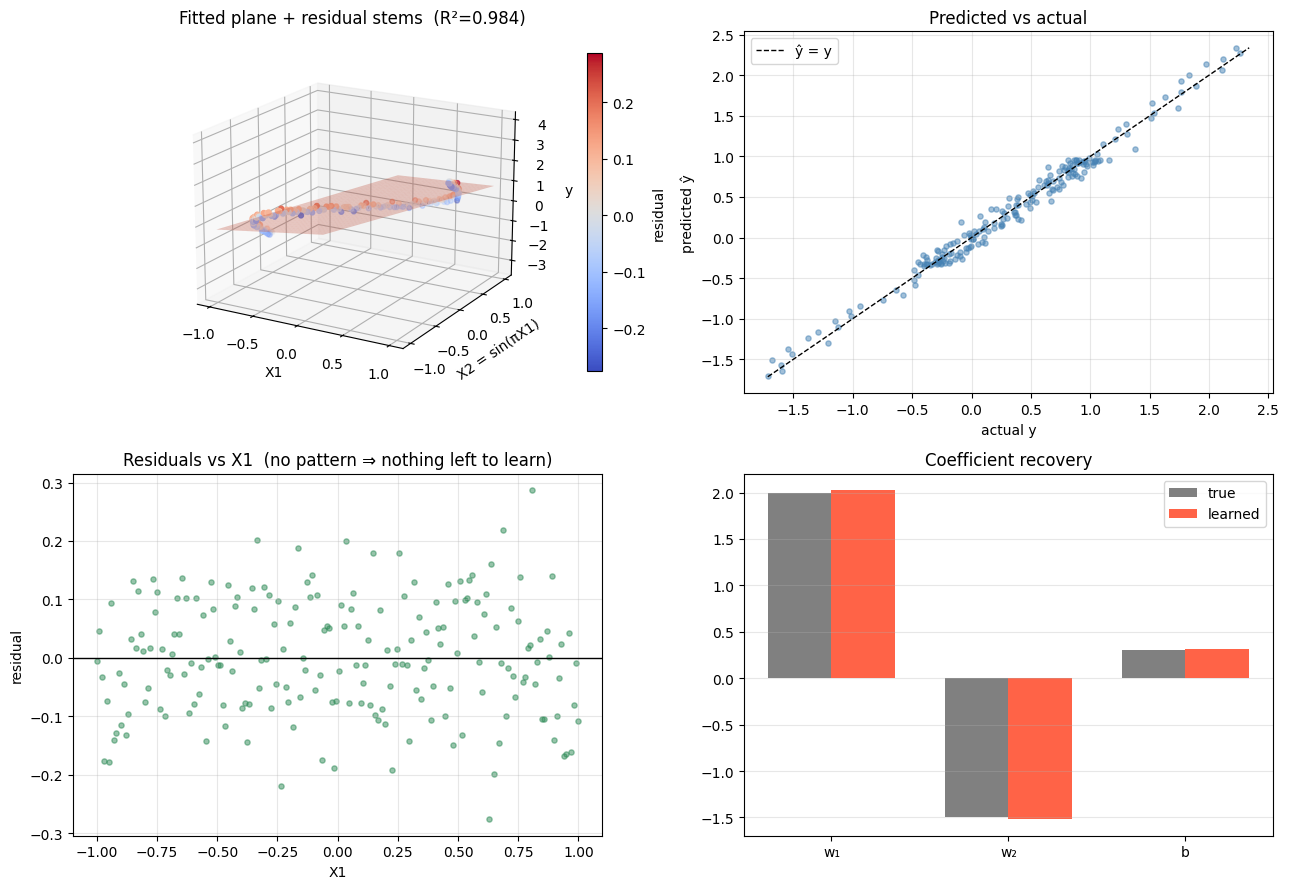

In [4]:
import numpy as np

torch.manual_seed(20000)

# --- data: two features; the second is a nonlinear function of the first ---
N = 200
X1 = torch.linspace(-1, 1, N)
X2 = torch.sin(torch.pi * X1)                 # second feature
X = torch.stack([X1, X2], dim=1)              # (N, 2)

true_w, true_b = torch.tensor([2.0, -1.5]), 0.3
y = X @ true_w + true_b + 0.1 * torch.randn(N)

# --- model + training (recording the loss) ---
model = nn.Linear(2, 1)
opt = torch.optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.MSELoss()
print('weight shape:', tuple(model.weight.shape), '  bias shape:', tuple(model.bias.shape))

loss_hist = []
for epoch in range(500):
    opt.zero_grad()
    loss = loss_fn(model(X).squeeze(), y)
    loss.backward(); opt.step()
    loss_hist.append(loss.item())

w_hat = model.weight.data.numpy().squeeze()
b_hat = model.bias.item()
with torch.no_grad():
    pred = model(X).squeeze()
resid = (y - pred).numpy()

# headline metrics
mse = float(((y - pred) ** 2).mean())
r2 = 1 - (resid ** 2).sum() / float(((y - y.mean()) ** 2).sum())
print(f"learned : w={w_hat.round(3)}, b={b_hat:.3f}")
print(f"true    : w={true_w.numpy()}, b={true_b}")
print(f"MSE={mse:.4f}   R²={r2:.4f}")

# --- diagnostics ---
x1n, x2n, yn, pn = X1.numpy(), X2.numpy(), y.numpy(), pred.numpy()
g = np.linspace(-1, 1, 30); G1, G2 = np.meshgrid(g, g)
Z_fit = w_hat[0] * G1 + w_hat[1] * G2 + b_hat

fig = plt.figure(figsize=(13, 9))

# (1) fitted plane + residual stems, points colored by signed residual
ax = fig.add_subplot(2, 2, 1, projection='3d')
ax.plot_surface(G1, G2, Z_fit, alpha=0.3, color='tomato', linewidth=0)
for xi, x2i, yi, pi in zip(x1n[::4], x2n[::4], yn[::4], pn[::4]):
    ax.plot([xi, xi], [x2i, x2i], [yi, pi], color='gray', lw=0.6)   # residual stem
sc = ax.scatter(x1n, x2n, yn, c=resid, cmap='coolwarm', s=12)
ax.set_title(f'Fitted plane + residual stems  (R²={r2:.3f})')
ax.set_xlabel('X1'); ax.set_ylabel('X2 = sin(πX1)'); ax.set_zlabel('y')
ax.view_init(elev=18, azim=-60)
fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.1, label='residual')

# (2) predicted vs actual
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(yn, pn, s=14, alpha=0.5, color='steelblue')
lim = [min(yn.min(), pn.min()), max(yn.max(), pn.max())]
ax2.plot(lim, lim, 'k--', lw=1, label='ŷ = y')
ax2.set_title('Predicted vs actual'); ax2.set_xlabel('actual y'); ax2.set_ylabel('predicted ŷ')
ax2.legend(); ax2.grid(alpha=0.3)

# (3) residuals vs input — should be structureless
ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(x1n, resid, s=14, alpha=0.5, color='seagreen')
ax3.axhline(0, color='k', lw=1)
ax3.set_title('Residuals vs X1  (no pattern ⇒ nothing left to learn)')
ax3.set_xlabel('X1'); ax3.set_ylabel('residual'); ax3.grid(alpha=0.3)

# (4) coefficient recovery
ax4 = fig.add_subplot(2, 2, 4)
xb = np.arange(3)
ax4.bar(xb - 0.18, [true_w[0].item(), true_w[1].item(), true_b], width=0.36, color='gray', label='true')
ax4.bar(xb + 0.18, [w_hat[0], w_hat[1], b_hat], width=0.36, color='tomato', label='learned')
ax4.set_xticks(xb); ax4.set_xticklabels(['w₁', 'w₂', 'b'])
ax4.set_title('Coefficient recovery'); ax4.legend(); ax4.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

**Reading the diagnostics.** Predicted-vs-actual sits tight on the diagonal, the residuals scatter around zero
with **no visible structure** (so a *linear* model is appropriate for this target), and the learned coefficients
match the truth — together a far clearer verdict than "the two planes look similar."

One subtle point: the data lives on a **1-D curve** inside the 2-D feature space (every point satisfies
`X2 = sin(π·X1)`). Because that curve is *nonlinear* it still bends through enough directions to pin both slopes
— but the plane's values *away* from the curve are pure **extrapolation**, unsupported by data. Recognizing
where a model is interpolating vs extrapolating is a habit worth forming early.

---

### What's next

You now own the loop that trains everything from a linear model to a variational quantum circuit. In the next
notebook — [**feature maps & kernels**](qadence-kickstart-101-kernels.ipynb) — we lift data into higher-dimensional
spaces and meet the **kernel trick**, the idea that becomes a *quantum* kernel (Pasqal's QEK) a few lessons
later. The training loop won't change; only the model will.